# Comparación de Arquitecturas — Retinopatía Diabética
## ResNet50 (baseline clásico) vs EfficientNet-B4 (competidor real)


Este notebook entrena y evalúa dos arquitecturas alternativas sobre el mismo dataset,
mismo preprocesamiento (CLAHE + filtro de oscuridad) y mismos hiperparámetros usados
en el modelo Swin-Tiny, para que la comparación sea justa.

| Modelo | Tipo | Parámetros | Objetivo |
|---|---|---|---|
| ResNet50 | CNN clásica | ~25M | Baseline de referencia |
| EfficientNet-B4 | CNN escalada | ~19M | Competidor real |
| Swin-Tiny *(ya entrenado)* | Transformer | ~28M | Modelo adoptado |

## 1. Instalación de dependencias

In [71]:
# Instalamos timm (modelos preentrenados) y kagglehub (descarga del dataset)
!pip install timm kagglehub -q

## 2. Importaciones

In [73]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
from collections import Counter
import glob  

import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
import timm

import kagglehub
from sklearn.metrics import f1_score, cohen_kappa_score, confusion_matrix

# Verificamos GPU disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Dispositivo: cuda
GPU: Tesla T4


## 3. Hiperparámetros globales
> Añadimos los mismos a los del notebook swin-tiny para comparación justa.

In [74]:
# ── Hiperparámetros ─────────────────────────────────────────────────────────
BATCH_SIZE  = 32       # mismo que Swin-Tiny
N_WORKERS   = 2        # mismo que Swin-Tiny
N_EPOCAS    = 5        # mismo que Swin-Tiny
PACIENCIA   = 3        # early stopping: mismo que Swin-Tiny
LR          = 1e-4     # mismo que Swin-Tiny
WEIGHT_DECAY= 1e-3     # mismo que Swin-Tiny
IMG_SIZE    = 224      # ResNet50 y EfficientNet-B4 aceptan 224px
N_CLASES    = 5        # RD0 → RD4
# ────────────────────────────────────────────────────────────────────────────
print("Hiperparámetros cargados correctamente")

Hiperparámetros cargados correctamente


## 4. Carga del dataset
> Mismo dataset EyePACS-APTOS-Messidor usado en el notebook original.

In [75]:
# Descargamos el dataset desde Kaggle Hub
path = '/kaggle/input/datasets/ascanipek/eyepacs-aptos-messidor-diabetic-retinopathy'

def cargar_split(split_name):
    """Lee todas las imágenes .jpg de un split y retorna un DataFrame con path y label."""
    split_path = os.path.join(path, "augmented_resized_V2", split_name)
    registros = []
    for root, _, files in os.walk(split_path):
        for file in files:
            if file.lower().endswith(".jpg"):
                registros.append({
                    "path":  os.path.join(root, file),
                    "label": int(os.path.basename(root))  # carpeta = grado RD
                })
    return pd.DataFrame(registros)

df_train = cargar_split("train")
df_val   = cargar_split("val")
df_test  = cargar_split("test")

print(f"Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}")
print("Distribución de clases en train:")
print(df_train["label"].value_counts().sort_index())

Train: 115241 | Val: 14227 | Test: 14201
Distribución de clases en train:
label
0    55162
1    18470
2    24198
3     7936
4     9475
Name: count, dtype: int64


## 5. Filtro de imágenes oscuras
> Mismo filtro del notebook original: se conservan imágenes con oscuridad entre 10% y 20%.

In [76]:
def clasificar_oscuridad(df, threshold=30):
    """
    Clasifica imágenes por porcentaje de píxeles oscuros (< threshold en escala gris).
    Devuelve listas de paths por rango de oscuridad.
    """
    oscuras_10 = []  # 10% < oscuridad <= 20%
    oscuras_20 = []  # oscuridad <= 10%

    for img_path in df['path'].tolist():
        img = cv2.imread(img_path)
        if img is None:
            continue
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        pct  = np.mean(gray < threshold) * 100

        if 10 < pct <= 20:
            oscuras_10.append(img_path)
        elif pct <= 10:
            oscuras_20.append(img_path)

    return oscuras_10, oscuras_20

print("Analizando imágenes de train (puede tardar unos minutos)...")
oscuras_10, oscuras_20 = clasificar_oscuridad(df_train)
print(f"  Imágenes con oscuridad 10-20%: {len(oscuras_10)}")
print(f"  Imágenes con oscuridad <=10% : {len(oscuras_20)}")

# Filtramos el train con las imagenes que son apropiadas para un analisis segun la retroalimentacion del especialista
paths_aceptados  = set(oscuras_10 + oscuras_20)
df_train_filtrado = df_train[df_train['path'].isin(paths_aceptados)].reset_index(drop=True)

# Val y test sin filtrar (simulan imágenes reales)
df_val_filtrado  = df_val.copy()
df_test_filtrado = df_test.copy()

print(f"\nTrain filtrado: {len(df_train_filtrado)} | Val: {len(df_val_filtrado)} | Test: {len(df_test_filtrado)}")

Analizando imágenes de train (puede tardar unos minutos)...
  Imágenes con oscuridad 10-20%: 56170
  Imágenes con oscuridad <=10% : 7440

Train filtrado: 63610 | Val: 14227 | Test: 14201


## 6. Dataset personalizado y transforms
> Clase `Retinopatia_Dataset` idéntica al notebook original.

In [79]:
class Retinopatia_Dataset(Dataset):
    """
    Dataset de retinopatía diabética.
    Aplica CLAHE en espacio LAB para mejorar el contraste de las imágenes de fondo de ojo.
    """
    def __init__(self, df, transform=None, apply_clahe=False):
        self.dataframe   = df.reset_index(drop=True)
        self.transform   = transform
        self.apply_clahe = apply_clahe
        # clipLimit=2.0 y tileGridSize=(8,8) igual que en Swin-Tiny
        self.clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]['path']
        label    = self.dataframe.iloc[idx]['label']

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.apply_clahe:
            lab       = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
            l, a, b   = cv2.split(lab)
            l_clahe   = self.clahe.apply(l)
            lab_clahe = cv2.merge((l_clahe, a, b))
            image     = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2RGB)

        image = Image.fromarray(image)
        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)


# ── Transforms (idénticos al notebook Swin-Tiny) ────────────────────────────
transform_train = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(degrees=360),       # augmentation rotación completa
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # normalización ImageNet
                         std=[0.229, 0.224, 0.225])
])

transform_val_test = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

print("Dataset y transforms definidos correctamente")

Dataset y transforms definidos correctamente


## 7. DataLoaders y pesos de clase
> Mismo WeightedRandomSampler y class_weights del notebook original para manejar desbalance.

In [80]:
def crear_loaders(df_tr, df_v, df_te):
    """
    Crea los DataLoaders con balanceo de clases por WeightedRandomSampler.
    Devuelve (loader_train, loader_val, loader_test, class_weights).
    """
    # Datasets
    ds_train = Retinopatia_Dataset(df_tr, transform=transform_train,    apply_clahe=True)
    ds_val   = Retinopatia_Dataset(df_v,  transform=transform_val_test, apply_clahe=True)
    ds_test  = Retinopatia_Dataset(df_te, transform=transform_val_test, apply_clahe=True)

    # WeightedRandomSampler — igual que en Swin-Tiny
    conteo        = df_tr["label"].value_counts().sort_index()
    peso_por_clase= 1.0 / conteo
    pesos_img     = df_tr["label"].map(dict(zip(conteo.index, peso_por_clase))).values
    sampler       = WeightedRandomSampler(torch.DoubleTensor(pesos_img),
                                          len(pesos_img), replacement=True)

    # Class weights para CrossEntropyLoss
    total        = len(df_tr)
    cw           = torch.tensor([total / (N_CLASES * conteo[i]) for i in range(N_CLASES)],
                                 dtype=torch.float).to(device)

    # Loaders
    ldr_train = DataLoader(ds_train, batch_size=BATCH_SIZE, sampler=sampler,
                           num_workers=N_WORKERS, pin_memory=True)
    ldr_val   = DataLoader(ds_val,   batch_size=BATCH_SIZE,
                           num_workers=N_WORKERS, pin_memory=True)
    ldr_test  = DataLoader(ds_test,  batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=N_WORKERS, pin_memory=True)

    return ldr_train, ldr_val, ldr_test, cw

loader_train, loader_val, loader_test, class_weights = crear_loaders(
    df_train_filtrado, df_val_filtrado, df_test_filtrado
)
print(f"Loaders creados — train batches: {len(loader_train)} | val batches: {len(loader_val)}")

Loaders creados — train batches: 1988 | val batches: 445


In [82]:

def cargar_checkpoint(modelo, optimizador, scheduler, nombre_modelo):
    """Carga el checkpoint más reciente si existe."""
    checkpoints = sorted(
        glob.glob(f"/kaggle/working/ckpt_{nombre_modelo}_ep*.pt")
    )
    if not checkpoints:
        print(f"  Sin checkpoint previo para {nombre_modelo}, inicio desde cero.")
        historial_vacio = {"perdidas": [], "qwk_val": [],
                           "f1_val": [], "mejor_qwk": 0.0}
        return 0, 0.0, historial_vacio

    ultimo = checkpoints[-1]
    cp = torch.load(ultimo, map_location=device, weights_only=False)
    modelo.load_state_dict(cp["model_state"])
    optimizador.load_state_dict(cp["optimizer_state"])
    scheduler.load_state_dict(cp["scheduler_state"])
    print(f"  [→] Reanudando desde {ultimo} (época {cp['epoca']})")
    return cp["epoca"], cp["mejor_qwk"], cp["historial"]

## 8. Función de entrenamiento genérica
> Una sola función reutilizable para ambas arquitecturas.

In [84]:
def entrenar_modelo(modelo, nombre_modelo, ruta_guardado,
                    loader_tr, loader_v, cw,
                    n_epocas=N_EPOCAS, paciencia=PACIENCIA):
    modelo = modelo.to(device)
    optimizador = AdamW(modelo.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler   = CosineAnnealingWarmRestarts(optimizador, T_0=5, T_mult=1)
    criterio    = nn.CrossEntropyLoss(weight=cw)

    historial = {"perdidas": [], "qwk_val": [], "f1_val": [], "mejor_qwk": 0.0}
    mejor_qwk       = 0.0
    epocas_sin_mejora = 0

    print(f"\n{'='*55}")
    print(f"  Entrenando: {nombre_modelo}")
    print(f"{'='*55}")

    epoca_inicio, mejor_qwk, historial = cargar_checkpoint(
        modelo, optimizador, scheduler, nombre_modelo)
    historial["mejor_qwk"] = mejor_qwk

    for epoca in range(epoca_inicio, n_epocas):
        # ── Fase de entrenamiento ────────────────────────────
        modelo.train()
        perdida_total = 0.0
        for imagenes, etiquetas in loader_tr:
            imagenes  = imagenes.to(device)
            etiquetas = etiquetas.to(device)
            optimizador.zero_grad()
            outputs = modelo(imagenes)
            perdida = criterio(outputs, etiquetas)
            perdida.backward()
            optimizador.step()
            perdida_total += perdida.item()
        perdida_promedio = perdida_total / len(loader_tr)

        # ── Fase de validación ───────────────────────────────
        modelo.eval()
        preds_val, etiq_val = [], []
        with torch.no_grad():
            for imgs_v, etqs_v in loader_v:
                imgs_v = imgs_v.to(device)
                outs_v = modelo(imgs_v)
                _, pred = torch.max(outs_v, 1)
                preds_val.extend(pred.cpu().numpy())
                etiq_val.extend(etqs_v.numpy())

        qwk = cohen_kappa_score(etiq_val, preds_val, weights="quadratic")
        f1  = f1_score(etiq_val, preds_val, average="macro", zero_division=0)

        historial["perdidas"].append(round(perdida_promedio, 4))
        historial["qwk_val"].append(round(qwk, 4))
        historial["f1_val"].append(round(f1, 4))

        print(f"  Época {epoca+1}/{n_epocas} | Pérdida: {perdida_promedio:.4f} "
              f"| QWK: {qwk:.4f} | F1-macro: {f1:.4f}")

        # ── Guardar mejor modelo ─────────────────────────────
        if qwk > mejor_qwk:
            mejor_qwk         = qwk
            epocas_sin_mejora = 0
            torch.save(modelo.state_dict(), ruta_guardado)
            os.sync()  # ← ERROR 1 corregido: era os,sync()
            print(f"  Mejor modelo guardado — QWK: {mejor_qwk:.4f}")
        else:
            epocas_sin_mejora += 1

        # ── Checkpoint ──────────────────────────────────────
        checkpoint = {
            "epoca":           epoca + 1,
            "model_state":     modelo.state_dict(),
            "optimizer_state": optimizador.state_dict(),
            "scheduler_state": scheduler.state_dict(),
            "mejor_qwk":       mejor_qwk,
            "historial":       historial,
        }
        torch.save(checkpoint,
            f"/kaggle/working/ckpt_{nombre_modelo}_ep{epoca+1}.pt")
        print(f"  Checkpoint guardado: época {epoca+1}")

        # ── Early stopping ───────────────────────────────────
        
        if epocas_sin_mejora >= paciencia:
            print(f"  Early stopping activado en época {epoca+1}")
            break

        scheduler.step()  # ERROR 3 corregido: debe estar dentro del for

    historial["mejor_qwk"] = mejor_qwk
    print(f"\n  Mejor QWK validación ({nombre_modelo}): {mejor_qwk:.4f}")
    return historial

print("Función de entrenamiento lista")

Función de entrenamiento lista


## 9. Función de evaluación en test

In [88]:
def evaluar_en_test(modelo, ruta_guardado, loader_te, nombre_modelo):
    """
    Carga los pesos del mejor modelo y evalúa sobre el set de test.
    Retorna métricas y muestra matriz de confusión.
    """
    modelo.load_state_dict(torch.load(ruta_guardado, map_location=device))
    modelo = modelo.to(device)
    modelo.eval()

    preds_test, etiq_test = [], []

    with torch.no_grad():
        for imgs_t, etqs_t in loader_te:
            imgs_t  = imgs_t.to(device)
            outs_t  = modelo(imgs_t)
            _, pred = torch.max(outs_t, 1)
            preds_test.extend(pred.cpu().numpy())
            etiq_test.extend(etqs_t.numpy())

    qwk = cohen_kappa_score(etiq_test, preds_test, weights="quadratic")
    f1  = f1_score(etiq_test, preds_test, average="macro", zero_division=0)

    print(f"── Resultados TEST — {nombre_modelo} ──────────────────────")
    print(f"   QWK  (quadratic weighted kappa): {qwk:.4f}")
    print(f"   F1-macro:                        {f1:.4f}")

    # Matriz de confusión
    cm = confusion_matrix(etiq_test, preds_test)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[f'RD{i}' for i in range(5)],
                yticklabels=[f'RD{i}' for i in range(5)])
    plt.title(f'Matriz de Confusión — {nombre_modelo}')
    plt.ylabel('Etiqueta Real')
    plt.xlabel('Predicción')
    plt.tight_layout()
    plt.show()

    return {"qwk_test": round(qwk, 4), "f1_test": round(f1, 4),
            "preds": preds_test, "etiquetas": etiq_test}


print("Función de evaluación lista")

Función de evaluación lista


---
## 10. Modelo 1 — ResNet50 

### ¿Por qué ResNet50 ?
- Arquitectura CNN estándar desde 2015 (He et al.), ampliamente citada en literatura médica.
- Usa bloques residuales (skip connections) que evitan el problema del gradiente desvaneciente.
- Su desempeño en retinopatía está bien documentado → sirve como piso de comparación.
- Si Swin-Tiny lo supera en QWK, justifica la elección del transformer.

```
Input 224×224 -> Conv1 -> BN -> ReLU -> MaxPool
-> Layer1 (3 bloques) -> Layer2 (4 bloques) -> Layer3 (6 bloques) -> Layer4 (3 bloques)
-> AvgPool -> FC(5) -> Softmax
```

In [89]:
# Creamos ResNet50 con pesos preentrenados en ImageNet
# num_classes=5 reemplaza la cabeza original (1000 clases) por nuestra tarea
modelo_resnet       = timm.create_model('resnet50',         pretrained=True, num_classes=N_CLASES)


# Verificamos la arquitectura de la cabeza
print("Cabeza clasificadora ResNet50:")
print(modelo_resnet.fc)

# Contamos parámetros totales y entrenables
total_params     = sum(p.numel() for p in modelo_resnet.parameters())
entrena_params   = sum(p.numel() for p in modelo_resnet.parameters() if p.requires_grad)
print(f"\nParámetros totales:     {total_params:,}")
print(f"Parámetros entrenables: {entrena_params:,}")

Cabeza clasificadora ResNet50:
Linear(in_features=2048, out_features=5, bias=True)

Parámetros totales:     23,518,277
Parámetros entrenables: 23,518,277


In [91]:
# Entrenamos ResNet50
historial_resnet = entrenar_modelo(
    modelo     = modelo_resnet,
    nombre_modelo  = "ResNet50",
    ruta_guardado  = "/kaggle/working//mejor_resnet50.pt",
    loader_tr  = loader_train,
    loader_v   = loader_val,
    cw         = class_weights
)


  Entrenando: ResNet50
  Sin checkpoint previo para ResNet50, inicio desde cero.
  Época 1/5 | Pérdida: 1.0818 | QWK: 0.6774 | F1-macro: 0.4848
  Mejor modelo guardado — QWK: 0.6774
  Checkpoint guardado: época 1
  Época 2/5 | Pérdida: 0.8538 | QWK: 0.6818 | F1-macro: 0.5197
  Mejor modelo guardado — QWK: 0.6818
  Checkpoint guardado: época 2
  Época 3/5 | Pérdida: 0.7352 | QWK: 0.6866 | F1-macro: 0.5241
  Mejor modelo guardado — QWK: 0.6866
  Checkpoint guardado: época 3
  Época 4/5 | Pérdida: 0.6616 | QWK: 0.6788 | F1-macro: 0.5185
  Checkpoint guardado: época 4
  Época 5/5 | Pérdida: 0.6210 | QWK: 0.7048 | F1-macro: 0.5336
  Mejor modelo guardado — QWK: 0.7048
  Checkpoint guardado: época 5

  Mejor QWK validación (ResNet50): 0.7048


── Resultados TEST — ResNet50 ──────────────────────
   QWK  (quadratic weighted kappa): 0.7135
   F1-macro:                        0.4520


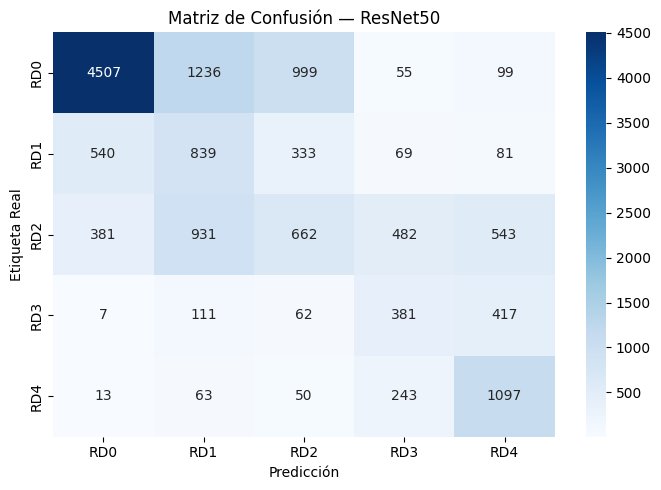

In [95]:
# Evaluamos ResNet50 en el set de test
resultados_resnet = evaluar_en_test(
    modelo        = modelo_resnet,
    ruta_guardado = "/kaggle/working/mejor_resnet50.pt",
    loader_te     = loader_test,
    nombre_modelo = "ResNet50"
)

---
Modelo 2 — EfficientNet-B4 

### ¿Por qué EfficientNet-B4?
- Arquitectura ganadora en competencias de Kaggle de retinopatía (EyePACS 2019).
- Usa compound scaling: escala simultáneamente profundidad, ancho y resolución con un coeficiente .
- Con solo 19M parámetros logra rendimiento superior a ResNet50 (~25M).
- Es el modelo de referencia de la industria para diagnóstico de fondo de ojo.

```
Input 224×224 -> Stem Conv
-> MBConv Blocks ×7 (con SE attention)
-> Head Conv → AvgPool → Dropout(0.4) -> FC(5) -> Softmax
```

In [93]:
# Creamos EfficientNet-B4 con pesos preentrenados en ImageNet
modelo_efficientnet = timm.create_model('efficientnet_b4',  pretrained=True, num_classes=N_CLASES)

# Verificamos la cabeza clasificadora
print("Cabeza clasificadora EfficientNet-B4:")
print(modelo_efficientnet.classifier)

# Contamos parámetros
total_params_eff   = sum(p.numel() for p in modelo_efficientnet.parameters())
entrena_params_eff = sum(p.numel() for p in modelo_efficientnet.parameters() if p.requires_grad)
print(f"\nParámetros totales:     {total_params_eff:,}")
print(f"Parámetros entrenables: {entrena_params_eff:,}")

model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

Cabeza clasificadora EfficientNet-B4:
Linear(in_features=1792, out_features=5, bias=True)

Parámetros totales:     17,557,581
Parámetros entrenables: 17,557,581


In [96]:
# Entrenamos EfficientNet-B4
# Nota: EfficientNet-B4 fue diseñado para 380px pero acepta 224px con buen rendimiento.
# Para máximo rendimiento, cambiar IMG_SIZE = 380 en la celda de hiperparámetros.
historial_efficientnet = entrenar_modelo(
    modelo        = modelo_efficientnet,
    nombre_modelo = "EfficientNet-B4",
    ruta_guardado = "/kaggle/working/mejor_efficientnet_b4.pt",
    loader_tr     = loader_train,
    loader_v      = loader_val,
    cw            = class_weights
)


  Entrenando: EfficientNet-B4
  Sin checkpoint previo para EfficientNet-B4, inicio desde cero.
  Época 1/5 | Pérdida: 0.9405 | QWK: 0.6191 | F1-macro: 0.4725
  Mejor modelo guardado — QWK: 0.6191
  Checkpoint guardado: época 1
  Época 2/5 | Pérdida: 0.7288 | QWK: 0.7152 | F1-macro: 0.5403
  Mejor modelo guardado — QWK: 0.7152
  Checkpoint guardado: época 2
  Época 3/5 | Pérdida: 0.5812 | QWK: 0.6818 | F1-macro: 0.5161
  Checkpoint guardado: época 3
  Época 4/5 | Pérdida: 0.4930 | QWK: 0.7099 | F1-macro: 0.5483
  Checkpoint guardado: época 4
  Época 5/5 | Pérdida: 0.4556 | QWK: 0.7055 | F1-macro: 0.5348
  Checkpoint guardado: época 5
  Early stopping activado en época 5

  Mejor QWK validación (EfficientNet-B4): 0.7152


── Resultados TEST — EfficientNet-B4 ──────────────────────
   QWK  (quadratic weighted kappa): 0.7218
   F1-macro:                        0.4793


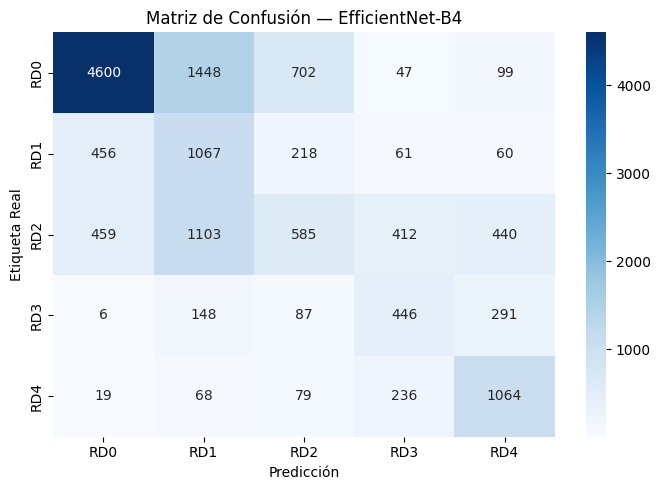

In [97]:
# Evaluamos EfficientNet-B4 en el set de test
resultados_efficientnet = evaluar_en_test(
    modelo        = modelo_efficientnet,
    ruta_guardado = "/kaggle/working/mejor_efficientnet_b4.pt",
    loader_te     = loader_test,
    nombre_modelo = "EfficientNet-B4"
)

---
## 12. Comparación final de los tres modelos

Incluimos los resultados del Swin-Tiny del notebook original para la comparación completa.

In [103]:
# ── Resultados del Swin-Tiny  ────────────────────────
QWK_SWIN      = 0.7616  # Swin original
F1_SWIN       = 0.58

QWK_SWIN_2F   = 0.7627  # Swin con 2 fases
F1_SWIN_2F    = 0.6392

resumen = pd.DataFrame({
    "Modelo":     ["ResNet50", "EfficientNet-B4", "Swin-Tiny", "Swin-Tiny (2 fases)"],
    "Tipo":       ["CNN clásica", "CNN escalada", "Transformer", "Transformer"],
    "Parámetros": ["~25M", "~19M", "~28M", "~28M"],
    "QWK Test":   [resultados_resnet["qwk_test"],
                   resultados_efficientnet["qwk_test"],
                   QWK_SWIN,
                   QWK_SWIN_2F],
    "F1-Macro":   [resultados_resnet["f1_test"],
                   resultados_efficientnet["f1_test"],
                   F1_SWIN,
                   F1_SWIN_2F],
})

resumen = resumen.sort_values("QWK Test", ascending=False).reset_index(drop=True)
resumen.index = resumen.index + 1  # ranking desde 1
print("\n══ TABLA COMPARATIVA FINAL ══")
print(resumen.to_string())


══ TABLA COMPARATIVA FINAL ══
                Modelo          Tipo Parámetros  QWK Test  F1-Macro
1  Swin-Tiny (2 fases)   Transformer       ~28M    0.7627    0.6392
2            Swin-Tiny   Transformer       ~28M    0.7616    0.5800
3      EfficientNet-B4  CNN escalada       ~19M    0.7218    0.4793
4             ResNet50   CNN clásica       ~25M    0.7135    0.4520


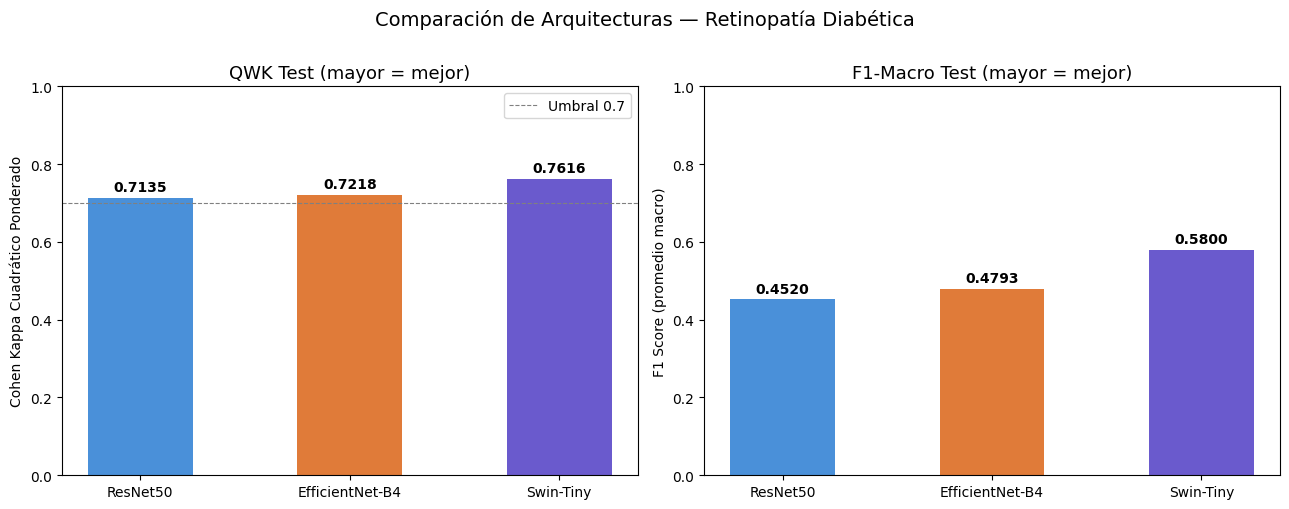

In [105]:
# ── Gráfica 1: QWK comparativo ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colores = ['#4a90d9', '#e07b39', '#6a5acd']
modelos = ["ResNet50", "EfficientNet-B4", "Swin-Tiny"]
qwk_vals= [resultados_resnet["qwk_test"],
            resultados_efficientnet["qwk_test"],
            QWK_SWIN]
f1_vals = [resultados_resnet["f1_test"],
            resultados_efficientnet["f1_test"],
            F1_SWIN]

bars1 = axes[0].bar(modelos, qwk_vals, color=colores, width=0.5)
axes[0].set_title('QWK Test (mayor = mejor)', fontsize=13)
axes[0].set_ylabel('Cohen Kappa Cuadrático Ponderado')
axes[0].set_ylim(0, 1)
axes[0].axhline(y=0.7, color='gray', linestyle='--', linewidth=0.8, label='Umbral 0.7')
for bar, val in zip(bars1, qwk_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center', va='bottom', fontweight='bold')
axes[0].legend()

bars2 = axes[1].bar(modelos, f1_vals, color=colores, width=0.5)
axes[1].set_title('F1-Macro Test (mayor = mejor)', fontsize=13)
axes[1].set_ylabel('F1 Score (promedio macro)')
axes[1].set_ylim(0, 1)
for bar, val in zip(bars2, f1_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

plt.suptitle('Comparación de Arquitecturas — Retinopatía Diabética', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# ── Gráfica 2: Curvas de entrenamiento lado a lado ───────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

epocas_r = list(range(1, len(historial_resnet["perdidas"]) + 1))
epocas_e = list(range(1, len(historial_efficientnet["perdidas"]) + 1))

# Pérdida ResNet50
axes[0,0].plot(epocas_r, historial_resnet["perdidas"], marker='o', color='#4a90d9')
axes[0,0].set_title('ResNet50 — Pérdida por época')
axes[0,0].set_xlabel('Época')
axes[0,0].set_ylabel('CrossEntropyLoss')

# QWK ResNet50
axes[0,1].plot(epocas_r, historial_resnet["qwk_val"], marker='o', color='#4a90d9')
axes[0,1].axhline(y=QWK_SWIN, color='#6a5acd', linestyle='--',
                   linewidth=1.2, label=f'Swin-Tiny QWK={QWK_SWIN}')
axes[0,1].set_title('ResNet50 — QWK Validación por época')
axes[0,1].set_xlabel('Época')
axes[0,1].set_ylabel('QWK')
axes[0,1].legend(fontsize=9)

# Pérdida EfficientNet-B4
axes[1,0].plot(epocas_e, historial_efficientnet["perdidas"], marker='o', color='#e07b39')
axes[1,0].set_title('EfficientNet-B4 — Pérdida por época')
axes[1,0].set_xlabel('Época')
axes[1,0].set_ylabel('CrossEntropyLoss')

# QWK EfficientNet-B4
axes[1,1].plot(epocas_e, historial_efficientnet["qwk_val"], marker='o', color='#e07b39')
axes[1,1].axhline(y=QWK_SWIN, color='#6a5acd', linestyle='--',
                   linewidth=1.2, label=f'Swin-Tiny QWK={QWK_SWIN}')
axes[1,1].set_title('EfficientNet-B4 — QWK Validación por época')
axes[1,1].set_xlabel('Época')
axes[1,1].set_ylabel('QWK')
axes[1,1].legend(fontsize=9)

plt.suptitle('Curvas de Entrenamiento por Arquitectura', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# ── Gráfica 3: Distribución real vs predicha en test ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
clases   = ['RD0', 'RD1', 'RD2', 'RD3', 'RD4']
x        = np.arange(5)
ancho    = 0.35

for ax, resultados, nombre, color in [
    (axes[0], resultados_resnet,       "ResNet50",        '#4a90d9'),
    (axes[1], resultados_efficientnet, "EfficientNet-B4", '#e07b39'),
]:
    conteo_real = [resultados["etiquetas"].count(i) for i in range(5)]
    conteo_pred = [resultados["preds"].count(i)     for i in range(5)]
    ax.bar(x - ancho/2, conteo_real, ancho, label='Real',    color='steelblue', alpha=0.8)
    ax.bar(x + ancho/2, conteo_pred, ancho, label='Predicho',color=color,       alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(clases)
    ax.set_title(f'{nombre} — Real vs Predicho (Test)')
    ax.set_ylabel('Cantidad de imágenes')
    ax.legend()

plt.suptitle('Distribución Real vs Predicha en Test', fontsize=14)
plt.tight_layout()
plt.show()